C:\Users\James\AppData\Local\Temp\ipykernel_16176\3305214122.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df_filtered, palette='Set2', ax=ax[1])


Success: All figures and animations saved.


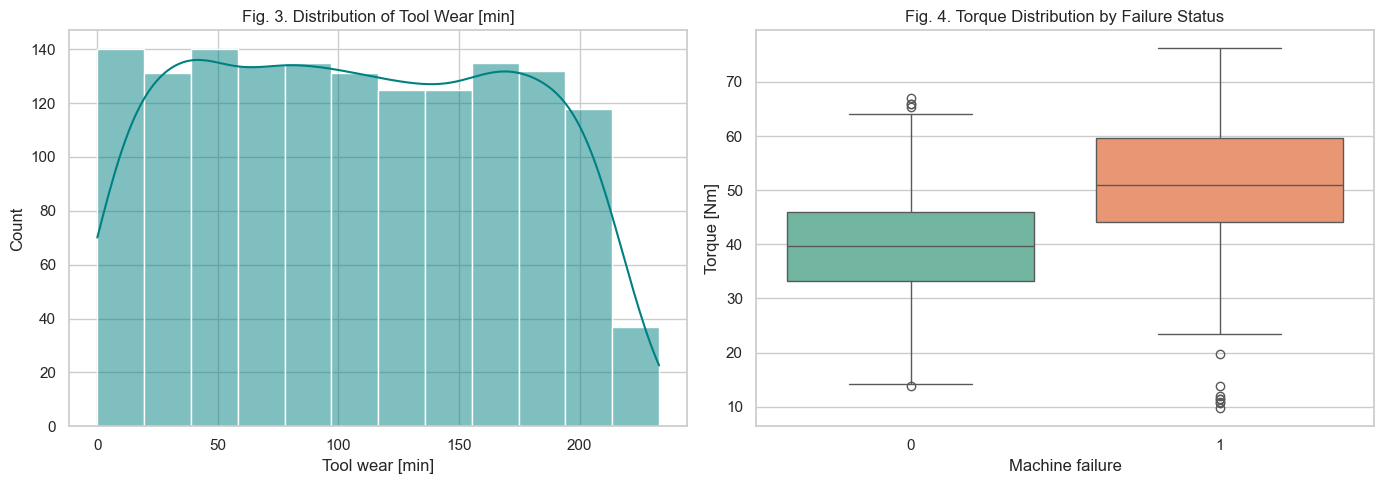

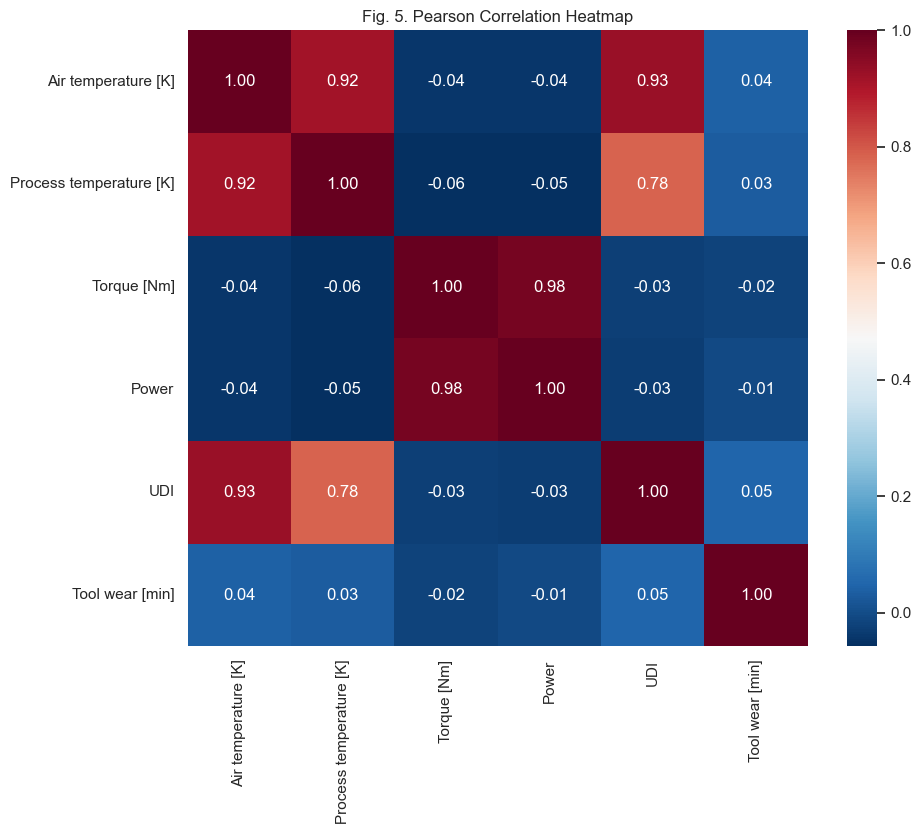

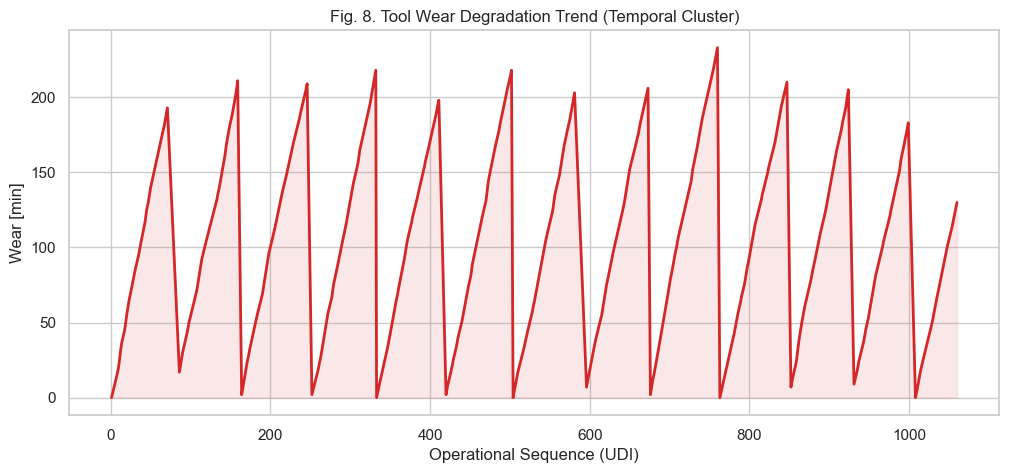

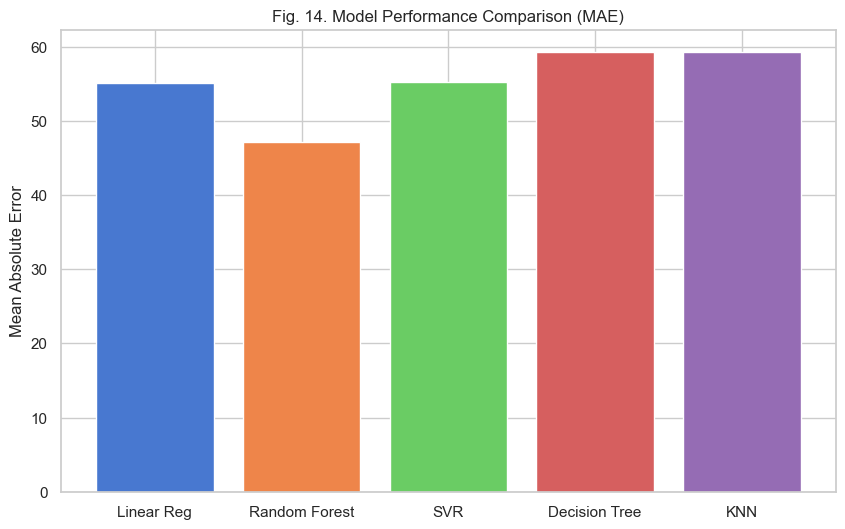

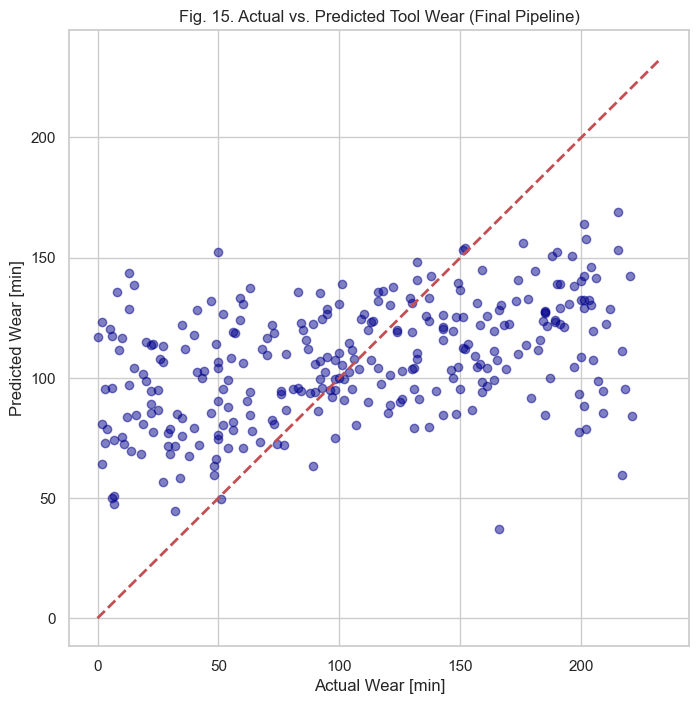

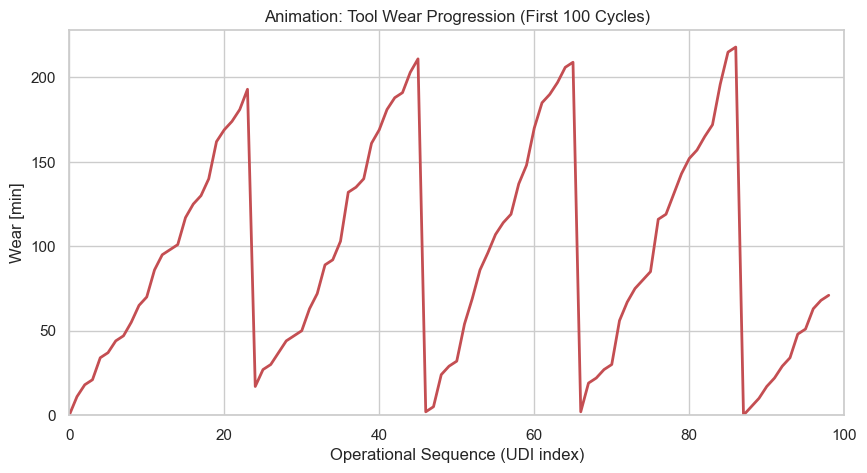

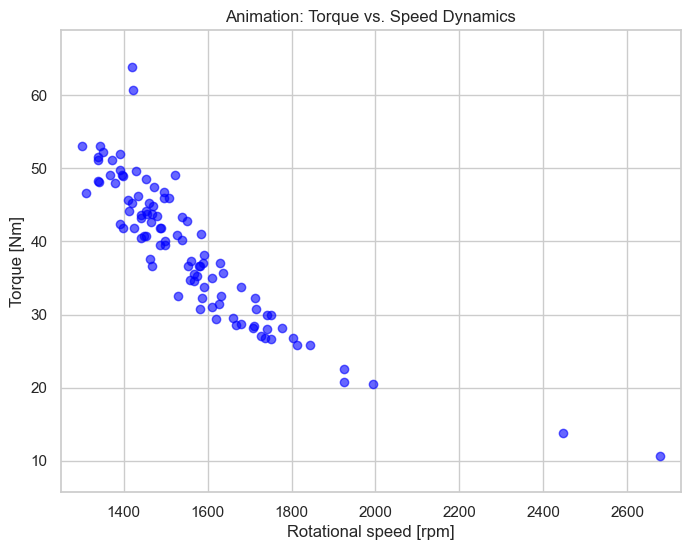

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# --- 1. DATA PREPARATION ---
# Load once to save memory
df = pd.read_csv('ai4i2020.csv')

# FIX: Clean column names to remove hidden non-breaking spaces (\xa0) or double spaces
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()

# Applying the Unique Filter (Type M, UDI 1-5000)
df_filtered = df[(df['Type'] == 'M') & (df['UDI'] <= 5000)].copy()

# Calculation using the cleaned column name
df_filtered['Power'] = df_filtered['Torque [Nm]'] * df_filtered['Rotational speed [rpm]']

features = ['Air temperature [K]', 'Process temperature [K]', 'Torque [Nm]', 'Power', 'UDI']
target = 'Tool wear [min]'

X = df_filtered[features]
y = df_filtered[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. THE VISUALIZATION SUITE ---
sns.set_theme(style="whitegrid")

# FIGURE A: DISTRIBUTION ANALYSIS
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_filtered[target], kde=True, color='teal', ax=ax[0])
ax[0].set_title('Fig. 3. Distribution of Tool Wear [min]')
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df_filtered, palette='Set2', ax=ax[1])
ax[1].set_title('Fig. 4. Torque Distribution by Failure Status')
plt.tight_layout()
plt.savefig('distribution_analysis.png')

# FIGURE B: CORRELATION HEATMAP
plt.figure(figsize=(10, 8))
sns.heatmap(df_filtered[features + [target]].corr(), annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('Fig. 5. Pearson Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

# FIGURE C: FEATURE TRENDS
plt.figure(figsize=(12, 5))
sample = df_filtered.sort_values('UDI').head(300)
plt.plot(sample['UDI'], sample[target], color='tab:red', linewidth=2)
plt.fill_between(sample['UDI'], sample[target], color='tab:red', alpha=0.1)
plt.title('Fig. 8. Tool Wear Degradation Trend (Temporal Cluster)')
plt.xlabel('Operational Sequence (UDI)')
plt.ylabel('Wear [min]')
plt.savefig('feature_trends.png')

# FIGURE D: MULTI-MODEL COMPARISON
models = {
    "Linear Reg": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}
mae_scores = {name: mean_absolute_error(y_test, m.fit(X_train, y_train).predict(X_test)) for name, m in models.items()}
plt.figure(figsize=(10, 6))
plt.bar(mae_scores.keys(), mae_scores.values(), color=sns.color_palette("muted"))
plt.title('Fig. 14. Model Performance Comparison (MAE)')
plt.ylabel('Mean Absolute Error')
plt.savefig('model_comparison.png')

# FIGURE E: ACTUAL VS PREDICTED
rf_model = models["Random Forest"]
y_pred = rf_model.predict(X_test)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='darkblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title('Fig. 15. Actual vs. Predicted Tool Wear (Final Pipeline)')
plt.xlabel('Actual Wear [min]')
plt.ylabel('Predicted Wear [min]')
plt.savefig('actual_vs_predicted.png')

# --- 3. ANIMATIONS ---
# Reuse the already cleaned and filtered data
ani_data = df_filtered.sort_values('UDI').head(100)

# ANIMATION 1: Tool Wear Progression
fig1, ax1 = plt.subplots(figsize=(10, 5))
line, = ax1.plot([], [], 'r-', lw=2)
ax1.set_xlim(0, 100)
ax1.set_ylim(0, ani_data['Tool wear [min]'].max() + 10)
ax1.set_title("Animation: Tool Wear Progression (First 100 Cycles)")
ax1.set_xlabel("Operational Sequence (UDI index)")
ax1.set_ylabel("Wear [min]")

def update_wear(frame):
    x = np.arange(frame)
    y = ani_data['Tool wear [min]'].iloc[:frame]
    line.set_data(x, y)
    return line,

ani1 = FuncAnimation(fig1, update_wear, frames=len(ani_data), interval=50, blit=True)
ani1.save('tool_wear_progression.gif', writer='pillow')

# ANIMATION 2: Torque vs. Speed Dynamics
fig2, ax2 = plt.subplots(figsize=(8, 6))
scat = ax2.scatter([], [], alpha=0.6, color='blue')
ax2.set_xlim(ani_data['Rotational speed [rpm]'].min()-50, ani_data['Rotational speed [rpm]'].max()+50)
ax2.set_ylim(ani_data['Torque [Nm]'].min()-5, ani_data['Torque [Nm]'].max()+5)
ax2.set_title("Animation: Torque vs. Speed Dynamics")
ax2.set_xlabel("Rotational speed [rpm]")
ax2.set_ylabel("Torque [Nm]")

def update_dynamics(frame):
    data = ani_data.iloc[:frame]
    scat.set_offsets(np.c_[data['Rotational speed [rpm]'], data['Torque [Nm]']])
    return scat,

ani2 = FuncAnimation(fig2, update_dynamics, frames=len(ani_data), interval=50, blit=True)
ani2.save('torque_speed_dynamics.gif', writer='pillow')

print("Success: All figures and animations saved.")